In [ ]:
# === BLOQUE 1: Configurar Kaggle ===
from google.colab import files
import os

print("Sube tu archivo kaggle.json (boton 'Elegir archivos' abajo)")
subido = files.upload()  # Aqui seleccionas tu kaggle.json

# Mover el token a la ubicacion que Kaggle espera
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("\nToken de Kaggle configurado correctamente.")

Sube tu archivo kaggle.json (boton 'Elegir archivos' abajo)


Saving kaggle.json to kaggle.json

Token de Kaggle configurado correctamente.


In [ ]:
# === BLOQUE 2: Descargar y explorar el dataset ===
import os
import subprocess

# Instalar la libreria de Kaggle (por si acaso)
subprocess.run(["pip", "install", "-q", "kaggle"])

# Descargar el dataset
print("Descargando dataset de Kaggle...")
subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "shahriar26s/banana-ripeness-classification-dataset",
    "-p", "/content/data"
])

# Descomprimir
print("Descomprimiendo...")
import zipfile
rutaZip = "/content/data/banana-ripeness-classification-dataset.zip"
with zipfile.ZipFile(rutaZip, "r") as zipRef:
    zipRef.extractall("/content/data/banana")

print("\nDataset descargado y descomprimido.\n")

# Explorar la estructura de carpetas
print("=" * 50)
print("ESTRUCTURA DEL DATASET")
print("=" * 50)

rutaBase = "/content/data/banana"
for raiz, carpetas, archivos in os.walk(rutaBase):
    nivel = raiz.replace(rutaBase, "").count(os.sep)
    sangria = "  " * nivel
    nombreCarpeta = os.path.basename(raiz)
    numImagenes = len([a for a in archivos if a.lower().endswith((".jpg", ".jpeg", ".png"))])
    if numImagenes > 0:
        print(f"{sangria}{nombreCarpeta}/ -> {numImagenes} imagenes")
    else:
        print(f"{sangria}{nombreCarpeta}/")

Descargando dataset de Kaggle...
Descomprimiendo...

Dataset descargado y descomprimido.

ESTRUCTURA DEL DATASET
banana/
  Banana Ripeness Classification Dataset/
    train/
      overripe/ -> 2349 imagenes
      ripe/ -> 3522 imagenes
      rotten/ -> 4020 imagenes
      unripe/ -> 1902 imagenes
    valid/
      overripe/ -> 229 imagenes
      ripe/ -> 339 imagenes
      rotten/ -> 388 imagenes
      unripe/ -> 167 imagenes
    test/
      overripe/ -> 113 imagenes
      ripe/ -> 154 imagenes
      rotten/ -> 185 imagenes
      unripe/ -> 110 imagenes


In [ ]:
# === BLOQUE CONFIG: Configuracion global (correr una sola vez) ===
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Rutas del dataset
rutaBase = "/content/data/banana/Banana Ripeness Classification Dataset"
rutaTrain = os.path.join(rutaBase, "train")
rutaValid = os.path.join(rutaBase, "valid")
rutaTest  = os.path.join(rutaBase, "test")

# Clases (nombres reales de las carpetas, en ingles)
clases = ["unripe", "ripe", "overripe", "rotten"]

# Traduccion a espanol (para informe y GUI)
nombresEspanol = {"unripe": "Verde", "ripe": "Maduro",
                  "overripe": "Sobremaduro", "rotten": "Podrido"}

# Colores para los graficos
coloresPlot = {"unripe": "green", "ripe": "gold",
               "overripe": "orange", "rotten": "brown"}

print("Configuracion global cargada.")
print(f"Clases: {clases}")
print(f"Ruta train: {rutaTrain}")

Configuracion global cargada.
Clases: ['unripe', 'ripe', 'overripe', 'rotten']
Ruta train: /content/data/banana/Banana Ripeness Classification Dataset/train


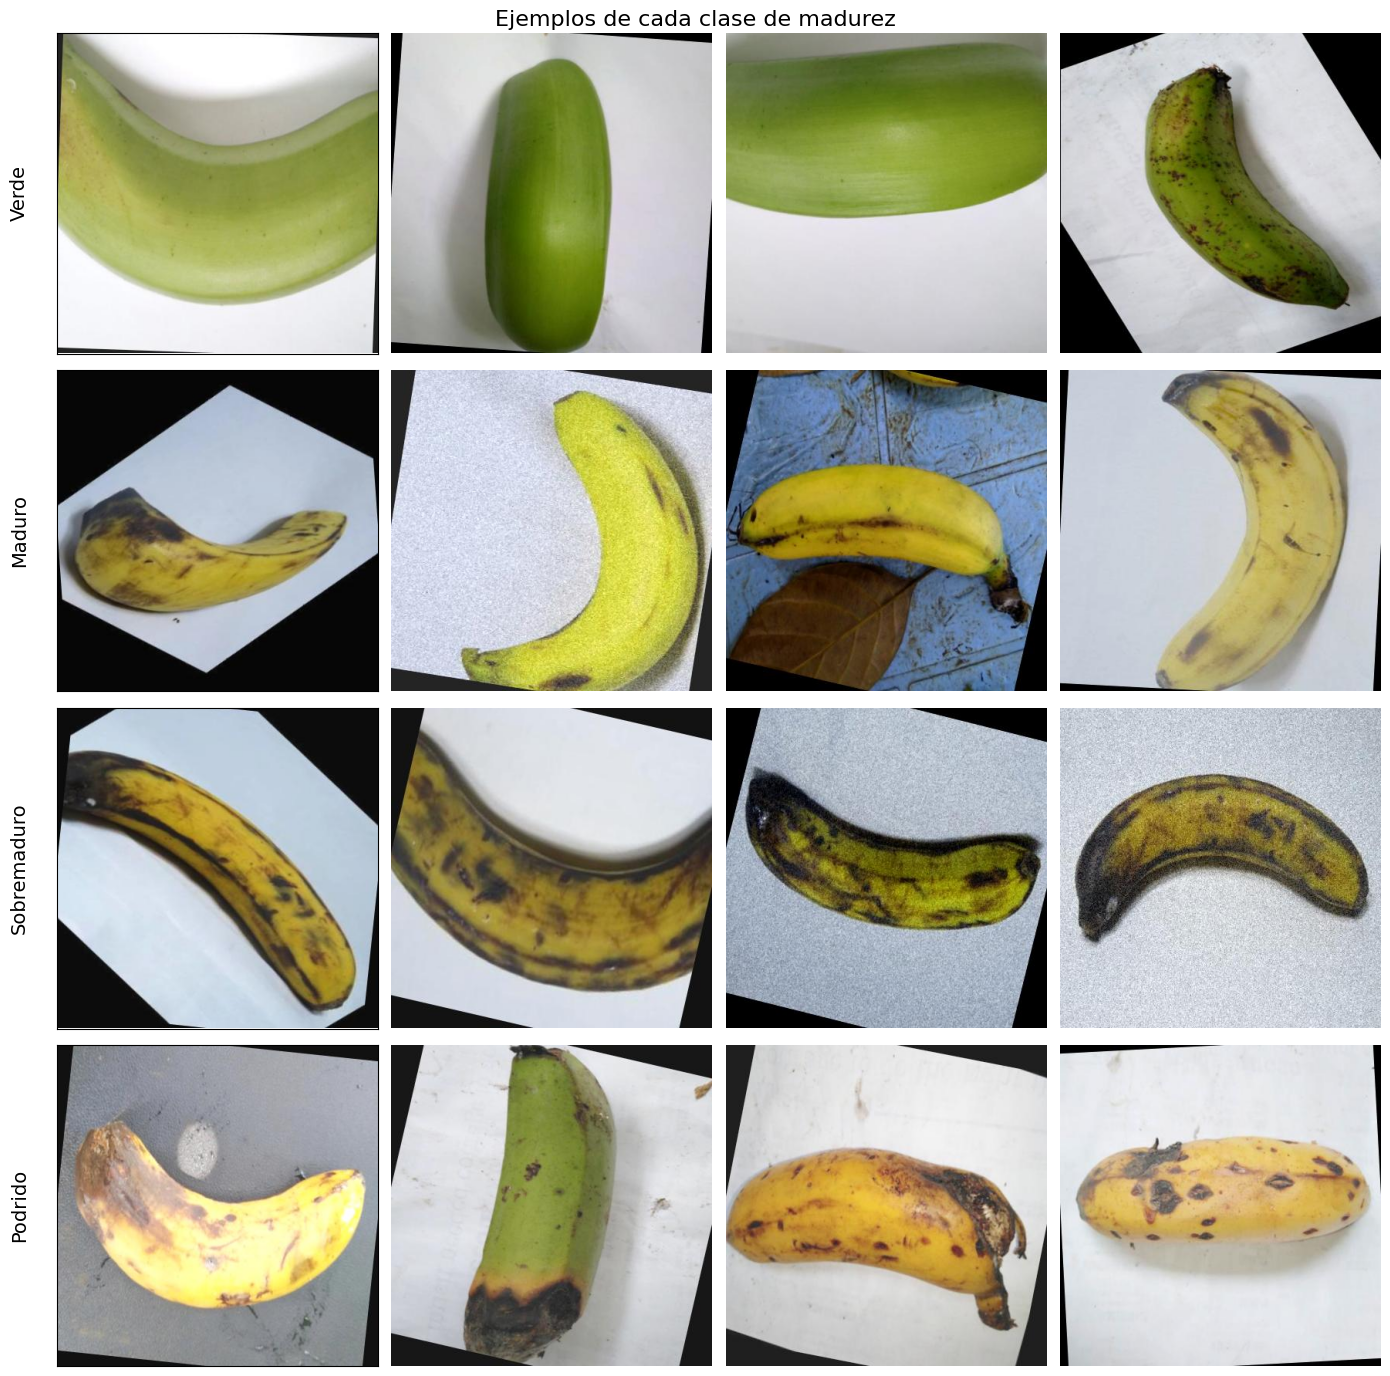

In [ ]:
# === BLOQUE 3: Exploracion visual del dataset ===

# Mostrar 4 imagenes de ejemplo por cada clase
fig, ejes = plt.subplots(len(clases), 4, figsize=(14, 14))

for fila, clase in enumerate(clases):
    rutaClase = os.path.join(rutaTrain, clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))]
    ejemplos = archivos[:4]  # primeras 4 imagenes

    for col, nombreArchivo in enumerate(ejemplos):
        rutaImg = os.path.join(rutaClase, nombreArchivo)
        img = cv2.imread(rutaImg)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV lee en BGR, convertir a RGB
        ejes[fila, col].imshow(img)
        ejes[fila, col].axis("off")
        if col == 0:
            ejes[fila, col].set_ylabel(nombresEspanol[clase], fontsize=14,
                                        rotation=90, labelpad=20)
            ejes[fila, col].axis("on")
            ejes[fila, col].set_xticks([])
            ejes[fila, col].set_yticks([])

plt.suptitle("Ejemplos de cada clase de madurez", fontsize=16)
plt.tight_layout()
plt.show()

Analizando colores por clase (esto toma ~30 segundos)...

Verde          -> Hue medio:   38.1 | mediana:   38.0
Maduro         -> Hue medio:   56.8 | mediana:   28.0
Sobremaduro    -> Hue medio:   27.8 | mediana:   22.0
Podrido        -> Hue medio:   43.7 | mediana:   22.0


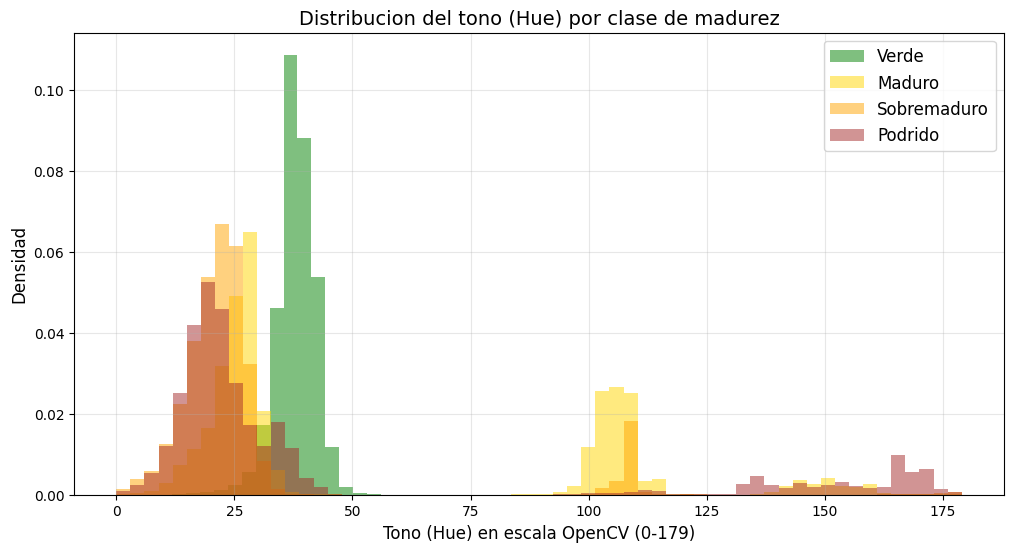


Referencia de tonos en OpenCV (Hue 0-179):
  Rojo: ~0-10 y ~170-179 | Naranja: ~10-25 | Amarillo: ~25-35
  Verde: ~35-85 | Azul: ~85-130


In [ ]:
# === BLOQUE 4: Analisis de colores HSV por clase ===

def obtenerPixelesFruta(rutaImg):
    """Lee una imagen, quita el fondo (blanco/negro) y devuelve los pixeles HSV de la fruta."""
    img = cv2.imread(rutaImg)
    img = cv2.resize(img, (200, 200))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Mascara para quitar fondo: descartar pixeles muy oscuros (negro) y muy claros/desaturados (blanco)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]
    mascaraFruta = (s > 40) & (v > 40) & (v < 250)
    pixelesHsv = hsv[mascaraFruta]
    return pixelesHsv

# Analizar una muestra de imagenes por clase (50 por clase para que sea rapido)
print("Analizando colores por clase (esto toma ~30 segundos)...\n")
datosHue = {}

for clase in clases:
    rutaClase = os.path.join(rutaTrain, clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))][:50]
    todosHue = []
    for nombreArchivo in archivos:
        pixeles = obtenerPixelesFruta(os.path.join(rutaClase, nombreArchivo))
        if len(pixeles) > 0:
            todosHue.extend(pixeles[:, 0])  # canal Hue (0-179 en OpenCV)
    datosHue[clase] = np.array(todosHue)
    hueMedia = np.mean(todosHue)
    hueMediana = np.median(todosHue)
    print(f"{nombresEspanol[clase]:14s} -> Hue medio: {hueMedia:6.1f} | mediana: {hueMediana:6.1f}")

# Graficar distribuciones de Hue
plt.figure(figsize=(12, 6))
for clase in clases:
    plt.hist(datosHue[clase], bins=60, alpha=0.5,
             label=nombresEspanol[clase], color=coloresPlot[clase], density=True)
plt.xlabel("Tono (Hue) en escala OpenCV (0-179)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.title("Distribucion del tono (Hue) por clase de madurez", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print("\nReferencia de tonos en OpenCV (Hue 0-179):")
print("  Rojo: ~0-10 y ~170-179 | Naranja: ~10-25 | Amarillo: ~25-35")
print("  Verde: ~35-85 | Azul: ~85-130")

In [ ]:
# === BLOQUE 5: Modelo clasico - Clasificador por segmentacion de color HSV ===

def extraerCaracteristicasColor(rutaImg):
    """
    Extrae un vector de caracteristicas de color de una imagen de platano.
    Devuelve las proporciones de pixeles de la fruta en cada zona de color.
    """
    img = cv2.imread(rutaImg)
    if img is None:
        return None
    img = cv2.resize(img, (200, 200))
    # Suavizado para reducir ruido (Gaussian Blur - Unidad 4 del silabo)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # Mascara de la fruta: quitar fondo blanco (muy claro/desaturado) y negro (muy oscuro)
    mascaraFruta = (s > 40) & (v > 40) & (v < 250)
    totalFruta = np.sum(mascaraFruta)
    if totalFruta == 0:
        return None

    # Definir zonas de color sobre los pixeles de la fruta (rangos de Hue en OpenCV 0-179)
    # Basados en el analisis del Bloque 4
    zonaVerde    = mascaraFruta & (h >= 35) & (h <= 85)               # tonos verdes
    zonaAmarillo = mascaraFruta & (h >= 22) & (h < 35)                # amarillo
    zonaNaranja  = mascaraFruta & (h >= 10) & (h < 22)                # naranja-marron
    # Zonas oscuras = manchas de maduracion/pudricion (poco brillo, dentro de la fruta)
    zonaOscura   = mascaraFruta & (v < 80)                            # manchas oscuras
    # Zonas de pudricion: tonos rojizos extremos
    zonaRojiza   = mascaraFruta & ((h >= 130) | (h <= 8)) & (s > 40)

    # Proporciones (porcentaje de la fruta en cada zona)
    propVerde    = np.sum(zonaVerde)    / totalFruta
    propAmarillo = np.sum(zonaAmarillo) / totalFruta
    propNaranja  = np.sum(zonaNaranja)  / totalFruta
    propOscura   = np.sum(zonaOscura)   / totalFruta
    propRojiza   = np.sum(zonaRojiza)   / totalFruta

    return {
        "verde": propVerde, "amarillo": propAmarillo, "naranja": propNaranja,
        "oscura": propOscura, "rojiza": propRojiza
    }


def clasificarPorReglas(carac):
    """
    Aplica reglas sobre el vector de caracteristicas para asignar la clase de madurez.
    Devuelve el nombre de la clase (en ingles, como las carpetas).
    """
    if carac is None:
        return "ripe"  # valor por defecto si falla la extraccion

    verde    = carac["verde"]
    oscura   = carac["oscura"]
    rojiza   = carac["rojiza"]

    # Regla 1: mucho verde -> Verde (unripe)
    if verde > 0.35:
        return "unripe"

    # Regla 2: mucha pudricion (zonas rojizas o demasiado oscuras) -> Podrido (rotten)
    if rojiza > 0.08 or oscura > 0.45:
        return "rotten"

    # Regla 3: bastantes manchas oscuras (pero no tanto) -> Sobremaduro (overripe)
    if oscura > 0.18:
        return "overripe"

    # Regla 4: por descarte, amarillo limpio -> Maduro (ripe)
    return "ripe"


# Prueba rapida con una imagen de cada clase para ver que funciona
print("Prueba del clasificador clasico con 1 imagen por clase:\n")
print(f"{'Clase real':14s} {'Prediccion':14s} {'verde':>7s} {'oscura':>7s} {'rojiza':>7s}")
print("-" * 60)

for clase in clases:
    rutaClase = os.path.join(rutaTrain, clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))]
    rutaImg = os.path.join(rutaClase, archivos[0])
    carac = extraerCaracteristicasColor(rutaImg)
    pred = clasificarPorReglas(carac)
    marca = "OK" if pred == clase else "X"
    print(f"{nombresEspanol[clase]:14s} {nombresEspanol[pred]:14s} "
          f"{carac['verde']:7.3f} {carac['oscura']:7.3f} {carac['rojiza']:7.3f}  {marca}")

print("\nClasificador clasico listo. Es una prueba pequena de 4 imagenes.")
print("En el siguiente bloque lo evaluaremos sobre TODO el conjunto de prueba (562 imagenes).")

Prueba del clasificador clasico con 1 imagen por clase:

Clase real     Prediccion       verde  oscura  rojiza
------------------------------------------------------------
Verde          Maduro           0.106   0.004   0.000  X
Maduro         Maduro           0.000   0.082   0.006  OK
Sobremaduro    Sobremaduro      0.000   0.193   0.006  OK
Podrido        Maduro           0.000   0.000   0.056  X

Clasificador clasico listo. Es una prueba pequena de 4 imagenes.
En el siguiente bloque lo evaluaremos sobre TODO el conjunto de prueba (562 imagenes).


In [ ]:
# === BLOQUE 5.5: Calibracion de umbrales con datos reales ===

def estadisticasCaracteristicas(rutaClase, nMuestras=100):
    """Calcula el promedio de cada caracteristica de color sobre una muestra de la clase."""
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))][:nMuestras]
    acumulado = {"verde": [], "amarillo": [], "naranja": [], "oscura": [], "rojiza": []}
    for nombreArchivo in archivos:
        carac = extraerCaracteristicasColor(os.path.join(rutaClase, nombreArchivo))
        if carac is not None:
            for k in acumulado:
                acumulado[k].append(carac[k])
    promedios = {k: np.mean(v) for k, v in acumulado.items()}
    return promedios

print("Midiendo caracteristicas promedio por clase (toma ~1 minuto)...\n")
print(f"{'Clase':14s} {'verde':>8s} {'amarillo':>9s} {'naranja':>8s} {'oscura':>8s} {'rojiza':>8s}")
print("-" * 62)

estadisticas = {}
for clase in clases:
    rutaClase = os.path.join(rutaTrain, clase)
    prom = estadisticasCaracteristicas(rutaClase)
    estadisticas[clase] = prom
    print(f"{nombresEspanol[clase]:14s} {prom['verde']:8.3f} {prom['amarillo']:9.3f} "
          f"{prom['naranja']:8.3f} {prom['oscura']:8.3f} {prom['rojiza']:8.3f}")

print("\n" + "=" * 62)
print("INTERPRETACION: que caracteristica distingue mejor cada clase")
print("=" * 62)
print("- Verde debe destacar en 'verde'")
print("- Maduro debe tener 'oscura' baja")
print("- Sobremaduro debe tener 'oscura' media-alta")
print("- Podrido debe destacar en 'rojiza' u 'oscura' muy alta")

Midiendo caracteristicas promedio por clase (toma ~1 minuto)...

Clase             verde  amarillo  naranja   oscura   rojiza
--------------------------------------------------------------
Verde             0.811     0.182    0.005    0.067    0.000
Maduro            0.008     0.577    0.128    0.062    0.068
Sobremaduro       0.001     0.417    0.516    0.327    0.036
Podrido           0.068     0.307    0.461    0.117    0.123

INTERPRETACION: que caracteristica distingue mejor cada clase
- Verde debe destacar en 'verde'
- Maduro debe tener 'oscura' baja
- Sobremaduro debe tener 'oscura' media-alta
- Podrido debe destacar en 'rojiza' u 'oscura' muy alta


In [ ]:
# === BLOQUE 5 (calibrado): Reglas con umbrales derivados de la tabla de caracteristicas ===

def clasificarPorReglas(carac):
    """
    Clasifica la madurez segun el vector de caracteristicas de color.
    Umbrales derivados de la huella de color promedio de cada clase (Bloque 5.5).
    """
    if carac is None:
        return "ripe"

    verde   = carac["verde"]
    naranja = carac["naranja"]
    oscura  = carac["oscura"]
    rojiza  = carac["rojiza"]

    # Regla 1: Verde se separa nitidamente (clase Verde tiene verde~0.81, el resto <0.07)
    if verde > 0.30:
        return "unripe"

    # Regla 2: Podrido -> destaca en rojiza (0.123 vs <0.07 en las demas)
    if rojiza > 0.09:
        return "rotten"

    # Regla 3: Sobremaduro -> oscura muy alta (0.327, la mas alta de todas)
    if oscura > 0.20:
        return "overripe"

    # Regla 4: Sobremaduro tambien se distingue por naranja alto + algo de oscura
    if naranja > 0.35 and oscura > 0.10:
        return "overripe"

    # Regla 5: por descarte, amarillo limpio (oscura y naranja bajas) -> Maduro
    return "ripe"


# Reverificar con 1 imagen por clase
print("Reverificacion con umbrales calibrados (1 imagen por clase):\n")
print(f"{'Clase real':14s} {'Prediccion':14s} {'verde':>7s} {'naranja':>8s} {'oscura':>7s} {'rojiza':>7s}")
print("-" * 68)

for clase in clases:
    rutaClase = os.path.join(rutaTrain, clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))]
    rutaImg = os.path.join(rutaClase, archivos[0])
    carac = extraerCaracteristicasColor(rutaImg)
    pred = clasificarPorReglas(carac)
    marca = "OK" if pred == clase else "X"
    print(f"{nombresEspanol[clase]:14s} {nombresEspanol[pred]:14s} "
          f"{carac['verde']:7.3f} {carac['naranja']:8.3f} {carac['oscura']:7.3f} "
          f"{carac['rojiza']:7.3f}  {marca}")

Reverificacion con umbrales calibrados (1 imagen por clase):

Clase real     Prediccion       verde  naranja  oscura  rojiza
--------------------------------------------------------------------
Verde          Maduro           0.106    0.001   0.004   0.000  X
Maduro         Maduro           0.000    0.117   0.082   0.006  OK
Sobremaduro    Maduro           0.000    0.344   0.193   0.006  X
Podrido        Maduro           0.000    0.697   0.000   0.056  X


Evaluando modelo clasico sobre 562 imagenes de prueba...
(toma ~1-2 minutos)

Accuracy global: 0.5925 (59.3%)
Tiempo total: 3.7s | Tiempo por imagen: 6.5 ms

REPORTE DE CLASIFICACION (modelo clasico)
              precision    recall  f1-score   support

       Verde      0.772     0.955     0.854       110
      Maduro      0.576     0.864     0.691       154
 Sobremaduro      0.465     0.593     0.521       113
     Podrido      0.549     0.151     0.237       185

    accuracy                          0.593       562
   macro avg      0.591     0.641     0.576       562
weighted avg      0.583     0.593     0.539       562



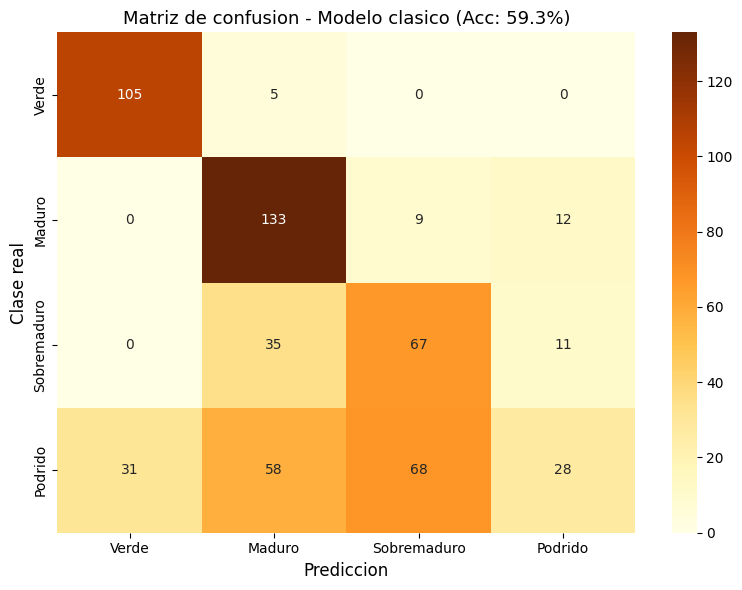


Resultados del modelo clasico guardados para la comparacion final.


In [ ]:
# === BLOQUE 6: Evaluacion completa del modelo clasico sobre el test set ===
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import time

print("Evaluando modelo clasico sobre 562 imagenes de prueba...")
print("(toma ~1-2 minutos)\n")

yReal = []
yPred = []
tiempoInicio = time.time()

for clase in clases:
    rutaClase = os.path.join(rutaTest, clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))]
    for nombreArchivo in archivos:
        rutaImg = os.path.join(rutaClase, nombreArchivo)
        carac = extraerCaracteristicasColor(rutaImg)
        pred = clasificarPorReglas(carac)
        yReal.append(clase)
        yPred.append(pred)

tiempoTotal = time.time() - tiempoInicio

# Accuracy global
acc = accuracy_score(yReal, yPred)
print(f"Accuracy global: {acc:.4f} ({acc*100:.1f}%)")
print(f"Tiempo total: {tiempoTotal:.1f}s | Tiempo por imagen: {tiempoTotal/len(yReal)*1000:.1f} ms\n")

# Reporte por clase (precision, recall, f1)
print("=" * 60)
print("REPORTE DE CLASIFICACION (modelo clasico)")
print("=" * 60)
nombresOrden = [nombresEspanol[c] for c in clases]
print(classification_report(yReal, yPred, labels=clases,
                            target_names=nombresOrden, digits=3, zero_division=0))

# Matriz de confusion
matriz = confusion_matrix(yReal, yPred, labels=clases)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=nombresOrden, yticklabels=nombresOrden)
plt.xlabel("Prediccion", fontsize=12)
plt.ylabel("Clase real", fontsize=12)
plt.title(f"Matriz de confusion - Modelo clasico (Acc: {acc*100:.1f}%)", fontsize=13)
plt.tight_layout()
plt.show()

# Guardar resultados para la comparacion final con el CNN
resultadosClasico = {"accuracy": acc, "yReal": yReal, "yPred": yPred,
                     "tiempoPorImagen_ms": tiempoTotal/len(yReal)*1000}
print("\nResultados del modelo clasico guardados para la comparacion final.")

In [ ]:
# === BLOQUE 7: Preparar generadores de datos para el CNN ===
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verificar que la GPU esta activa
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
print("Version TensorFlow:", tf.__version__, "\n")

# Parametros
TAMANO_IMG = (224, 224)   # tamano de entrada de MobileNetV2
BATCH = 32

# Generador de entrenamiento CON aumentacion de datos
# (rotaciones, volteos, zoom -> el modelo generaliza mejor)
genEntrenamiento = ImageDataGenerator(
    rescale=1./255,              # normalizar pixeles a [0,1]
    rotation_range=20,           # rotaciones aleatorias
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

# Generadores de validacion y test: SOLO normalizar (sin aumentacion)
genValidacion = ImageDataGenerator(rescale=1./255)
genTest = ImageDataGenerator(rescale=1./255)

# Crear los flujos de datos leyendo las carpetas
# classes= fija el orden de las clases igual que en el modelo clasico
flujoEntrenamiento = genEntrenamiento.flow_from_directory(
    rutaTrain, target_size=TAMANO_IMG, batch_size=BATCH,
    class_mode="categorical", classes=clases, shuffle=True
)
flujoValidacion = genValidacion.flow_from_directory(
    rutaValid, target_size=TAMANO_IMG, batch_size=BATCH,
    class_mode="categorical", classes=clases, shuffle=False
)
flujoTest = genTest.flow_from_directory(
    rutaTest, target_size=TAMANO_IMG, batch_size=BATCH,
    class_mode="categorical", classes=clases, shuffle=False
)

print("\nMapeo de clases (indice -> nombre):")
for nombre, indice in flujoEntrenamiento.class_indices.items():
    print(f"  {indice}: {nombre} ({nombresEspanol[nombre]})")

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Version TensorFlow: 2.20.0 

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.

Mapeo de clases (indice -> nombre):
  0: unripe (Verde)
  1: ripe (Maduro)
  2: overripe (Sobremaduro)
  3: rotten (Podrido)


In [ ]:
# === BLOQUE 8: Construir y entrenar el CNN (MobileNetV2 + transfer learning) ===
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- Calcular pesos de clase para compensar el desbalance ---
etiquetasTrain = flujoEntrenamiento.classes
pesos = compute_class_weight(class_weight="balanced",
                             classes=np.unique(etiquetasTrain),
                             y=etiquetasTrain)
pesosClase = {i: p for i, p in enumerate(pesos)}
print("Pesos de clase (compensan el desbalance):")
for i, p in pesosClase.items():
    print(f"  {i} ({nombresEspanol[clases[i]]}): {p:.3f}")

# --- Construir el modelo ---
print("\nConstruyendo MobileNetV2...")
baseModelo = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(224, 224, 3))
baseModelo.trainable = False  # congelar la base preentrenada

# Cabezal de clasificacion propio para nuestras 4 clases
x = baseModelo.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)          # dropout para reducir sobreajuste
salida = Dense(len(clases), activation="softmax")(x)

modeloCNN = Model(inputs=baseModelo.input, outputs=salida)

modeloCNN.compile(optimizer=Adam(learning_rate=0.001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

print(f"Parametros entrenables: {sum([tf.size(w).numpy() for w in modeloCNN.trainable_weights]):,}")

# --- Entrenar ---
paradaTemprana = EarlyStopping(monitor="val_loss", patience=3,
                               restore_best_weights=True, verbose=1)

print("\nEntrenando... (esto toma varios minutos con la GPU)\n")
historia = modeloCNN.fit(
    flujoEntrenamiento,
    validation_data=flujoValidacion,
    epochs=15,
    class_weight=pesosClase,
    callbacks=[paradaTemprana],
    verbose=1
)

print("\nEntrenamiento terminado.")

Pesos de clase (compensan el desbalance):
  0 (Verde): 1.550
  1 (Maduro): 0.837
  2 (Sobremaduro): 1.255
  3 (Podrido): 0.733

Construyendo MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parametros entrenables: 164,484

Entrenando... (esto toma varios minutos con la GPU)

Epoch 1/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 225s 549ms/step - accuracy: 0.8957 - loss: 0.2689 - val_accuracy: 0.9466 - val_loss: 0.1587
Epoch 2/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 171s 462ms/step - accuracy: 0.9379 - loss: 0.1560 - val_accuracy: 0.9475 - val_loss: 0.1538
Epoch 3/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 171s 463ms/step - accuracy: 0.9506 - loss: 0.1321 - val_accuracy: 0.9599 - val_loss: 0.1174
Epoch 4/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 170s 461ms/step - accuracy: 0.9557 - loss: 0.1165 - val_accuracy: 0.9608 - val_loss: 0.1272
Epoch 5/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 169s 458ms/step - accuracy: 0.9557 - loss: 0.1099 - val_accuracy: 0.9439 - val_loss: 0.1536
Epoch 6/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 168s 456m

Evaluando CNN sobre 562 imagenes de prueba...

18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 798ms/step

Accuracy global CNN: 0.9537 (95.4%)
Tiempo total: 23.2s | Tiempo por imagen: 41.4 ms

REPORTE DE CLASIFICACION (CNN)
              precision    recall  f1-score   support

       Verde      0.947     0.973     0.960       110
      Maduro      0.949     0.974     0.962       154
 Sobremaduro      0.964     0.938     0.951       113
     Podrido      0.956     0.935     0.945       185

    accuracy                          0.954       562
   macro avg      0.954     0.955     0.954       562
weighted avg      0.954     0.954     0.954       562



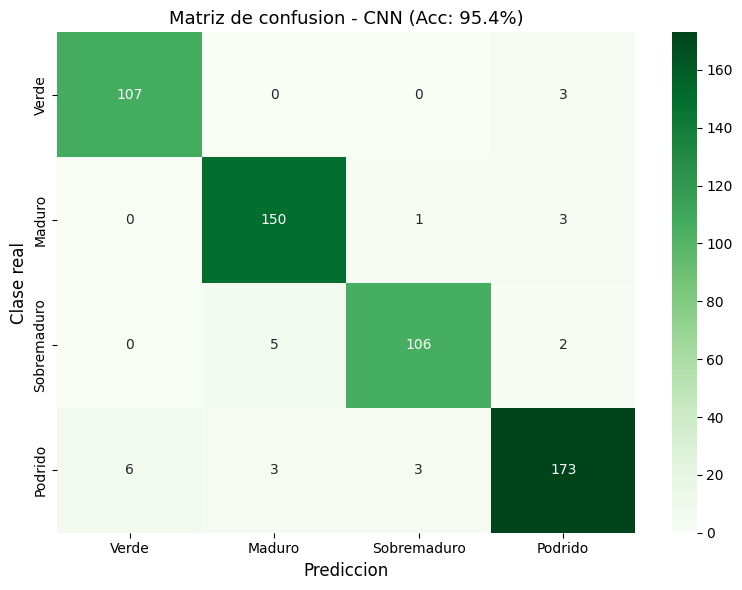


Resultados del CNN guardados para la comparacion final.


In [ ]:
# === BLOQUE 9: Evaluacion completa del CNN sobre el test set ===
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import time

print("Evaluando CNN sobre 562 imagenes de prueba...\n")

# Predecir sobre todo el test set
flujoTest.reset()
tiempoInicio = time.time()
probabilidades = modeloCNN.predict(flujoTest, verbose=1)
tiempoTotal = time.time() - tiempoInicio

yPredCNN_idx = np.argmax(probabilidades, axis=1)     # indice de la clase predicha
yRealCNN_idx = flujoTest.classes                      # indices reales

# Convertir indices a nombres de clase
yPredCNN = [clases[i] for i in yPredCNN_idx]
yRealCNN = [clases[i] for i in yRealCNN_idx]

# Accuracy global
accCNN = accuracy_score(yRealCNN, yPredCNN)
print(f"\nAccuracy global CNN: {accCNN:.4f} ({accCNN*100:.1f}%)")
print(f"Tiempo total: {tiempoTotal:.1f}s | Tiempo por imagen: {tiempoTotal/len(yRealCNN)*1000:.1f} ms\n")

# Reporte por clase
print("=" * 60)
print("REPORTE DE CLASIFICACION (CNN)")
print("=" * 60)
nombresOrden = [nombresEspanol[c] for c in clases]
print(classification_report(yRealCNN, yPredCNN, labels=clases,
                            target_names=nombresOrden, digits=3, zero_division=0))

# Matriz de confusion
matrizCNN = confusion_matrix(yRealCNN, yPredCNN, labels=clases)
plt.figure(figsize=(8, 6))
sns.heatmap(matrizCNN, annot=True, fmt="d", cmap="Greens",
            xticklabels=nombresOrden, yticklabels=nombresOrden)
plt.xlabel("Prediccion", fontsize=12)
plt.ylabel("Clase real", fontsize=12)
plt.title(f"Matriz de confusion - CNN (Acc: {accCNN*100:.1f}%)", fontsize=13)
plt.tight_layout()
plt.show()

# Guardar resultados para la comparacion final
resultadosCNN = {"accuracy": accCNN, "yReal": yRealCNN, "yPred": yPredCNN,
                 "tiempoPorImagen_ms": tiempoTotal/len(yRealCNN)*1000}
print("\nResultados del CNN guardados para la comparacion final.")

TABLA COMPARATIVA DE MODELOS
                          Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Tiempo/img (ms)
Modelo Clasico (HSV)         0.593              0.591           0.641       0.576            6.512
Modelo CNN (MobileNetV2)     0.954              0.954           0.955       0.954           41.367

RECALL POR CLASE (metrica principal)
      Clase  Recall Clasico  Recall CNN  Mejora
      Verde           0.955       0.973   0.018
     Maduro           0.864       0.974   0.110
Sobremaduro           0.593       0.938   0.345
    Podrido           0.151       0.935   0.784


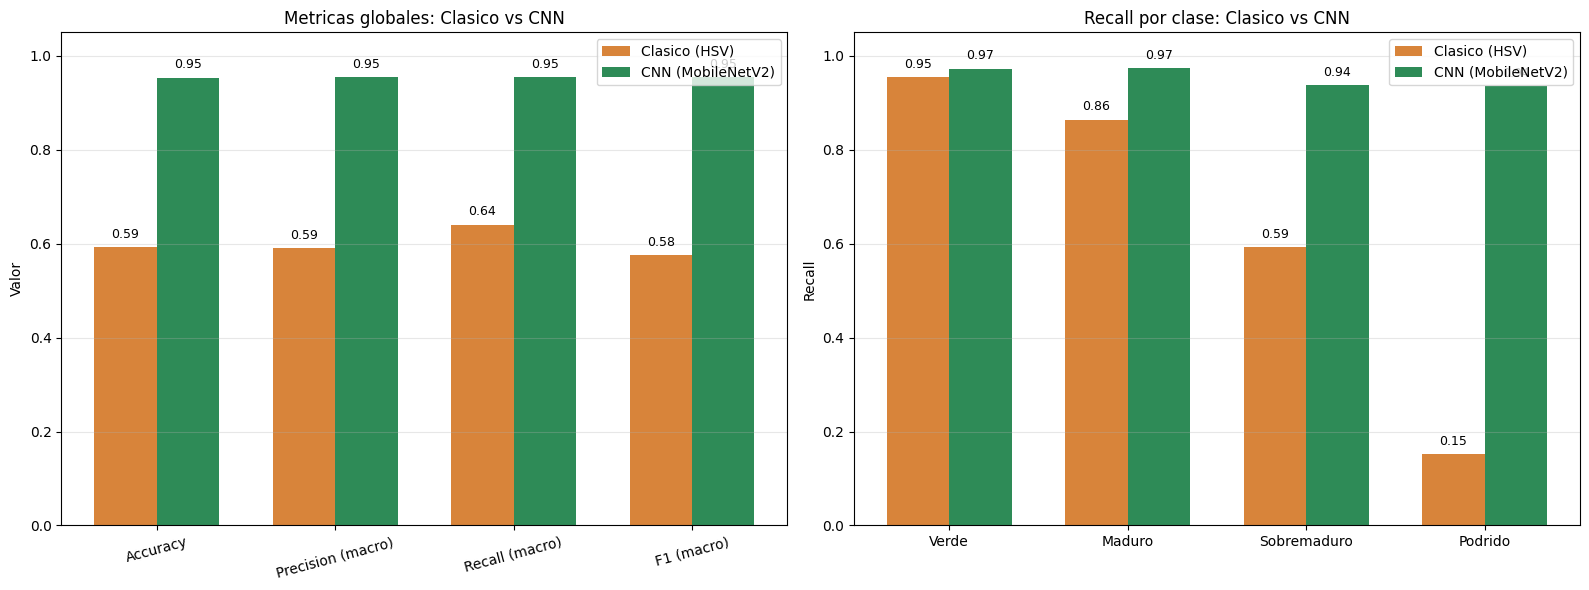


Grafico guardado como 'comparacion_modelos.png' (lo puedes descargar para el informe)


In [ ]:
# === BLOQUE 10: Comparacion final de ambos modelos ===
from sklearn.metrics import recall_score, precision_score, f1_score
import pandas as pd

# --- Tabla comparativa de metricas globales ---
def metricasGlobales(yReal, yPred):
    return {
        "Accuracy": accuracy_score(yReal, yPred),
        "Precision (macro)": precision_score(yReal, yPred, labels=clases, average="macro", zero_division=0),
        "Recall (macro)": recall_score(yReal, yPred, labels=clases, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yReal, yPred, labels=clases, average="macro", zero_division=0),
    }

mClasico = metricasGlobales(resultadosClasico["yReal"], resultadosClasico["yPred"])
mCNN = metricasGlobales(resultadosCNN["yReal"], resultadosCNN["yPred"])

tablaComparativa = pd.DataFrame({
    "Modelo Clasico (HSV)": mClasico,
    "Modelo CNN (MobileNetV2)": mCNN
}).T
tablaComparativa["Tiempo/img (ms)"] = [resultadosClasico["tiempoPorImagen_ms"],
                                        resultadosCNN["tiempoPorImagen_ms"]]

print("=" * 70)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 70)
print(tablaComparativa.round(3).to_string())
print()

# --- Recall por clase (la metrica principal segun el informe) ---
recallClasicoPorClase = recall_score(resultadosClasico["yReal"], resultadosClasico["yPred"],
                                     labels=clases, average=None, zero_division=0)
recallCNNPorClase = recall_score(resultadosCNN["yReal"], resultadosCNN["yPred"],
                                 labels=clases, average=None, zero_division=0)

tablaRecall = pd.DataFrame({
    "Clase": [nombresEspanol[c] for c in clases],
    "Recall Clasico": recallClasicoPorClase,
    "Recall CNN": recallCNNPorClase,
    "Mejora": recallCNNPorClase - recallClasicoPorClase
})
print("=" * 70)
print("RECALL POR CLASE (metrica principal)")
print("=" * 70)
print(tablaRecall.round(3).to_string(index=False))

# --- Grafico comparativo 1: metricas globales ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

metricas = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
x = np.arange(len(metricas))
ancho = 0.35
ax1.bar(x - ancho/2, [mClasico[m] for m in metricas], ancho,
        label="Clasico (HSV)", color="#D8843A")
ax1.bar(x + ancho/2, [mCNN[m] for m in metricas], ancho,
        label="CNN (MobileNetV2)", color="#2E8B57")
ax1.set_xticks(x)
ax1.set_xticklabels(metricas, rotation=15)
ax1.set_ylabel("Valor")
ax1.set_title("Metricas globales: Clasico vs CNN")
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(axis="y", alpha=0.3)
for i, m in enumerate(metricas):
    ax1.text(i - ancho/2, mClasico[m] + 0.02, f"{mClasico[m]:.2f}", ha="center", fontsize=9)
    ax1.text(i + ancho/2, mCNN[m] + 0.02, f"{mCNN[m]:.2f}", ha="center", fontsize=9)

# --- Grafico comparativo 2: recall por clase ---
xc = np.arange(len(clases))
ax2.bar(xc - ancho/2, recallClasicoPorClase, ancho, label="Clasico (HSV)", color="#D8843A")
ax2.bar(xc + ancho/2, recallCNNPorClase, ancho, label="CNN (MobileNetV2)", color="#2E8B57")
ax2.set_xticks(xc)
ax2.set_xticklabels([nombresEspanol[c] for c in clases])
ax2.set_ylabel("Recall")
ax2.set_title("Recall por clase: Clasico vs CNN")
ax2.legend()
ax2.set_ylim(0, 1.05)
ax2.grid(axis="y", alpha=0.3)
for i in range(len(clases)):
    ax2.text(i - ancho/2, recallClasicoPorClase[i] + 0.02, f"{recallClasicoPorClase[i]:.2f}", ha="center", fontsize=9)
    ax2.text(i + ancho/2, recallCNNPorClase[i] + 0.02, f"{recallCNNPorClase[i]:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGrafico guardado como 'comparacion_modelos.png' (lo puedes descargar para el informe)")

Sube una foto de un platano (boton abajo):



Saving platano.png to platano.png


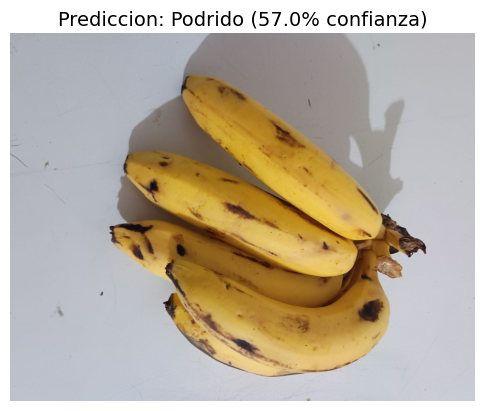

  CLASIFICACION: Podrido  (confianza 57.0%)

  Apto para consumo:  NO apto para consumo
  Ventana transporte: 0 dias (desecho)
  Mercado recomendado: Ninguno
  Observacion:        Separar del lote para evitar contaminacion.

  Probabilidades por clase:
    Verde         :  14.9%  ####
    Maduro        :  27.9%  ########
    Sobremaduro   :   0.2%  
    Podrido       :  57.0%  #################


In [ ]:
# === BLOQUE 11-B: Clasificador interactivo directo (sin Gradio) ===
from google.colab import files
import matplotlib.pyplot as plt

# infoLogistica ya esta definida del bloque anterior; si no, redefinir aqui:
infoLogistica = {
    "unripe": {"emoji": "VERDE", "apto": "No apto para consumo inmediato (requiere maduracion)",
               "ventana": "7-14 dias", "mercado": "Mercados lejanos / Exportacion",
               "obs": "Resistente al transporte. Puede madurar en destino."},
    "ripe": {"emoji": "MADURO", "apto": "Apto para consumo inmediato",
             "ventana": "3-7 dias", "mercado": "Mercados regionales / Consumo directo",
             "obs": "Estado optimo para venta al consumidor."},
    "overripe": {"emoji": "SOBREMADURO", "apto": "Apto, preferible para procesamiento industrial",
                 "ventana": "1-2 dias", "mercado": "Mercado local / Industria (pures, harina)",
                 "obs": "Alto riesgo de perdida. Comercializar con urgencia."},
    "rotten": {"emoji": "PODRIDO", "apto": "NO apto para consumo",
               "ventana": "0 dias (desecho)", "mercado": "Ninguno",
               "obs": "Separar del lote para evitar contaminacion."}
}

print("Sube una foto de un platano (boton abajo):\n")
subida = files.upload()  # aqui seleccionas tu foto

# Tomar el primer archivo subido
nombreArchivo = list(subida.keys())[0]

# Leer y preprocesar
imgOriginal = cv2.imread(nombreArchivo)
imgOriginal = cv2.cvtColor(imgOriginal, cv2.COLOR_BGR2RGB)
img = cv2.resize(imgOriginal, (224, 224)).astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

# Predecir con el CNN
probs = modeloCNN.predict(img, verbose=0)[0]
idxClase = np.argmax(probs)
claseIngles = clases[idxClase]
claseEspanol = nombresEspanol[claseIngles]
confianza = probs[idxClase] * 100
info = infoLogistica[claseIngles]

# Mostrar la imagen + resultado
plt.figure(figsize=(6, 6))
plt.imshow(imgOriginal)
plt.axis("off")
plt.title(f"Prediccion: {claseEspanol} ({confianza:.1f}% confianza)", fontsize=14)
plt.show()

# Reporte en texto
print("=" * 55)
print(f"  CLASIFICACION: {claseEspanol}  (confianza {confianza:.1f}%)")
print("=" * 55)
print(f"\n  Apto para consumo:  {info['apto']}")
print(f"  Ventana transporte: {info['ventana']}")
print(f"  Mercado recomendado: {info['mercado']}")
print(f"  Observacion:        {info['obs']}")
print(f"\n  Probabilidades por clase:")
for i, c in enumerate(clases):
    barra = "#" * int(probs[i] * 30)
    print(f"    {nombresEspanol[c]:14s}: {probs[i]*100:5.1f}%  {barra}")

In [ ]:
# === BLOQUE 12: Guardar el modelo CNN entrenado ===

# 1. Guardar el modelo en un archivo (.keras es el formato moderno de Keras)
rutaModelo = "/content/modelo_platanos_cnn.keras"
modeloCNN.save(rutaModelo)
print(f"Modelo guardado en: {rutaModelo}")

# Ver el tamano del archivo
import os
tamanoMB = os.path.getsize(rutaModelo) / (1024 * 1024)
print(f"Tamano del archivo: {tamanoMB:.1f} MB\n")

# 2. Respaldar en Google Drive (para compartir con el grupo y para la entrega)
from google.colab import drive
drive.mount('/content/drive')

# Crear una carpeta para el proyecto en tu Drive
carpetaDrive = "/content/drive/MyDrive/TrabajoFinal_PI"
os.makedirs(carpetaDrive, exist_ok=True)

# Copiar el modelo al Drive
import shutil
destinoDrive = os.path.join(carpetaDrive, "modelo_platanos_cnn.keras")
shutil.copy(rutaModelo, destinoDrive)
print(f"\nModelo respaldado en tu Drive: {destinoDrive}")
print("Ahora tus companeros pueden acceder a este archivo si compartes la carpeta.")

# 3. Tambien lo puedes descargar a tu PC directamente
from google.colab import files
print("\nDescargando el modelo a tu PC...")
files.download(rutaModelo)

Modelo guardado en: /content/modelo_platanos_cnn.keras
Tamano del archivo: 11.1 MB

Mounted at /content/drive

Modelo respaldado en tu Drive: /content/drive/MyDrive/TrabajoFinal_PI/modelo_platanos_cnn.keras
Ahora tus companeros pueden acceder a este archivo si compartes la carpeta.

Descargando el modelo a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>